In [ ]:
import re
import xml.etree.ElementTree as ET
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches




In [2]:
import config
from config import DATA_FOLDER2

XML_PATH = (
    DATA_FOLDER2 
    / "2023-07-26{6591E658-D0E0-49FE-BDE4-FC101EACF45D}.eeg" 
    / "ElectrodePlacements" 
    / "SEEG Hanna.xml"
)

# Check if the file actually exists at that path
if XML_PATH.exists():
    print("Found!")
else:
    print("File not found.")

Found!


In [3]:
def parse_seeg_xml(path: str) -> pd.DataFrame:
    tree = ET.parse(path)
    root = tree.getroot()
 
    records = []
    for order, el in enumerate(root.findall("Electrode")):
        label = el.find("Label").text
        x = float(el.find("XCoordinate").text)
        y = float(el.find("YCoordinate").text)
        channel_type = el.find("ChannelType").text
        group_id = el.find("GroupId").text
 
        
        m = re.match(r"^([A-Za-z]+)(\d+)$", label)
        shaft = m.group(1) if m else label
        contact_num = int(m.group(2)) if m else 0
 
        records.append(
            {
                "label": label,
                "shaft": shaft,
                "contact": contact_num,
                "x": x,
                "y": y,
                "channel_type": channel_type,
                "group_id": group_id,
                "order": order,
            }
        )
 
    return pd.DataFrame(records)
 

In [4]:
def draw_head_outline(ax, cx=0.5, cy=0.48, rx=0.58, ry=0.42):
    head = mpatches.Ellipse(
        (cx, cy), 2 * rx, 2 * ry, fill=True, facecolor="#f5f0eb",
        edgecolor="black", linewidth=1.5, zorder=0,
    )
    ax.add_patch(head)
 
    
    nose_y = cy - ry
    ax.plot(
        [cx - 0.02, cx, cx + 0.02],
        [nose_y, nose_y - 0.03, nose_y],
        color="black", linewidth=1.2, zorder=1,
    )
 
    
    for side in (-1, 1):
        ear = mpatches.Ellipse(
            (cx + side * (rx + 0.01), cy), 0.03, 0.08,
            facecolor="#f5f0eb", edgecolor="black", linewidth=1.0, zorder=1,
        )
        ax.add_patch(ear)
 
    ax.text(cx, cy - ry - 0.06, "front", ha="center", fontsize=8, color="grey")
    ax.text(cx, cy + ry + 0.06, "back", ha="center", fontsize=8, color="grey")
    ax.text(cx - rx - 0.07, cy, "L", ha="center", va="center", fontsize=9, color="grey")
    ax.text(cx + rx + 0.07, cy, "R", ha="center", va="center", fontsize=9, color="grey")
 
 

In [5]:
def plot_seeg(df: pd.DataFrame, save_path="seeg_illustration.png", scale=0.75):
    fig, ax = plt.subplots(figsize=(13, 11))
 
    draw_head_outline(ax)
 
    
    cx, cy = 0.5, 0.48
    df = df.copy()
    df["x_plot"] = cx + (df["x"] - cx) * scale
    df["y_plot"] = cy + (df["y"] - cy) * scale
 
    shafts = df["shaft"].unique()
    cmap = plt.colormaps["tab20"].resampled(len(shafts))
 
    for i, shaft in enumerate(shafts):
        sub = df[df["shaft"] == shaft].sort_values(
            "contact" if (df[df["shaft"] == shaft]["contact"] > 0).all() else "order"
        )
        color = cmap(i)
 
        ax.plot(sub["x_plot"], sub["y_plot"], color=color, linewidth=1.8, alpha=0.8, zorder=2)
        ax.scatter(
            sub["x_plot"], sub["y_plot"], color=color, s=55, edgecolor="black",
            linewidth=0.5, zorder=3,
        )
 
        first = sub.iloc[0]
        last = sub.iloc[-1]
    
        ax.annotate(
            shaft,
            xy=(first["x_plot"], first["y_plot"]),
            xytext=(first["x_plot"] - 0.015, first["y_plot"] - 0.02),
            fontsize=9, fontweight="bold", color=color, zorder=4,
        )
 
    ax.set_xlim(-0.15, 1.15)
    ax.set_ylim(1.15, -0.15)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(
        "SEEG electrodes' placement ",
        fontsize=13,
    )
 
    plt.tight_layout()
    plt.savefig(save_path, dpi=220, bbox_inches="tight")
    print(f"Saved image: {save_path}")
    plt.show()

Read contacts: 116, 12 electrodes:
['LFO', 'LPX', 'LTM', 'LTS', 'RD', 'RDM', 'RFO', 'RIA', 'RIP', 'RL', 'RM', 'RTS']
Saved image: seeg_illustration.png


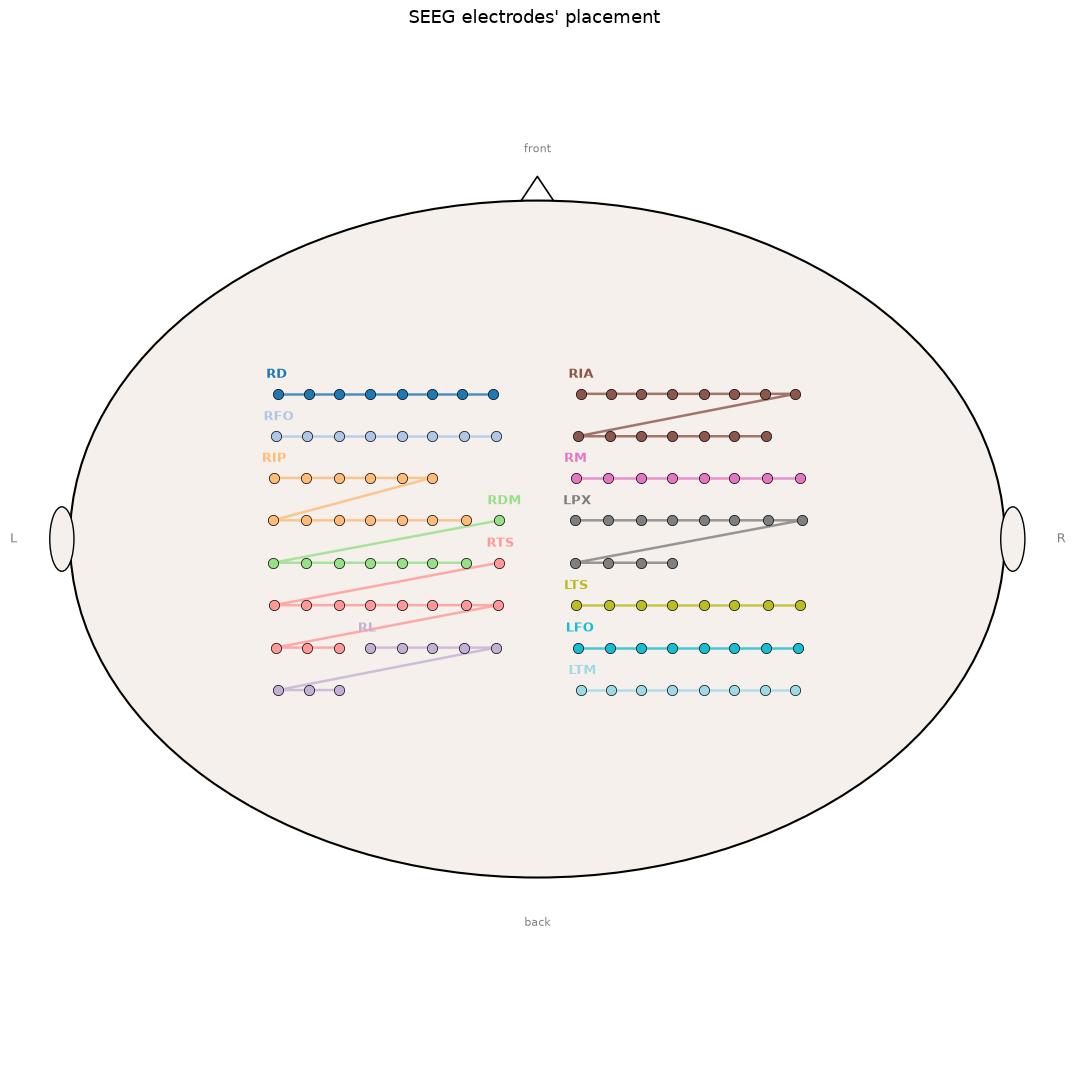

In [6]:
df = parse_seeg_xml(XML_PATH)
print(f"Read contacts: {len(df)}, {df['shaft'].nunique()} electrodes:")
print(sorted(df["shaft"].unique()))
plot_seeg(df)

Parsed 116 electrode contacts


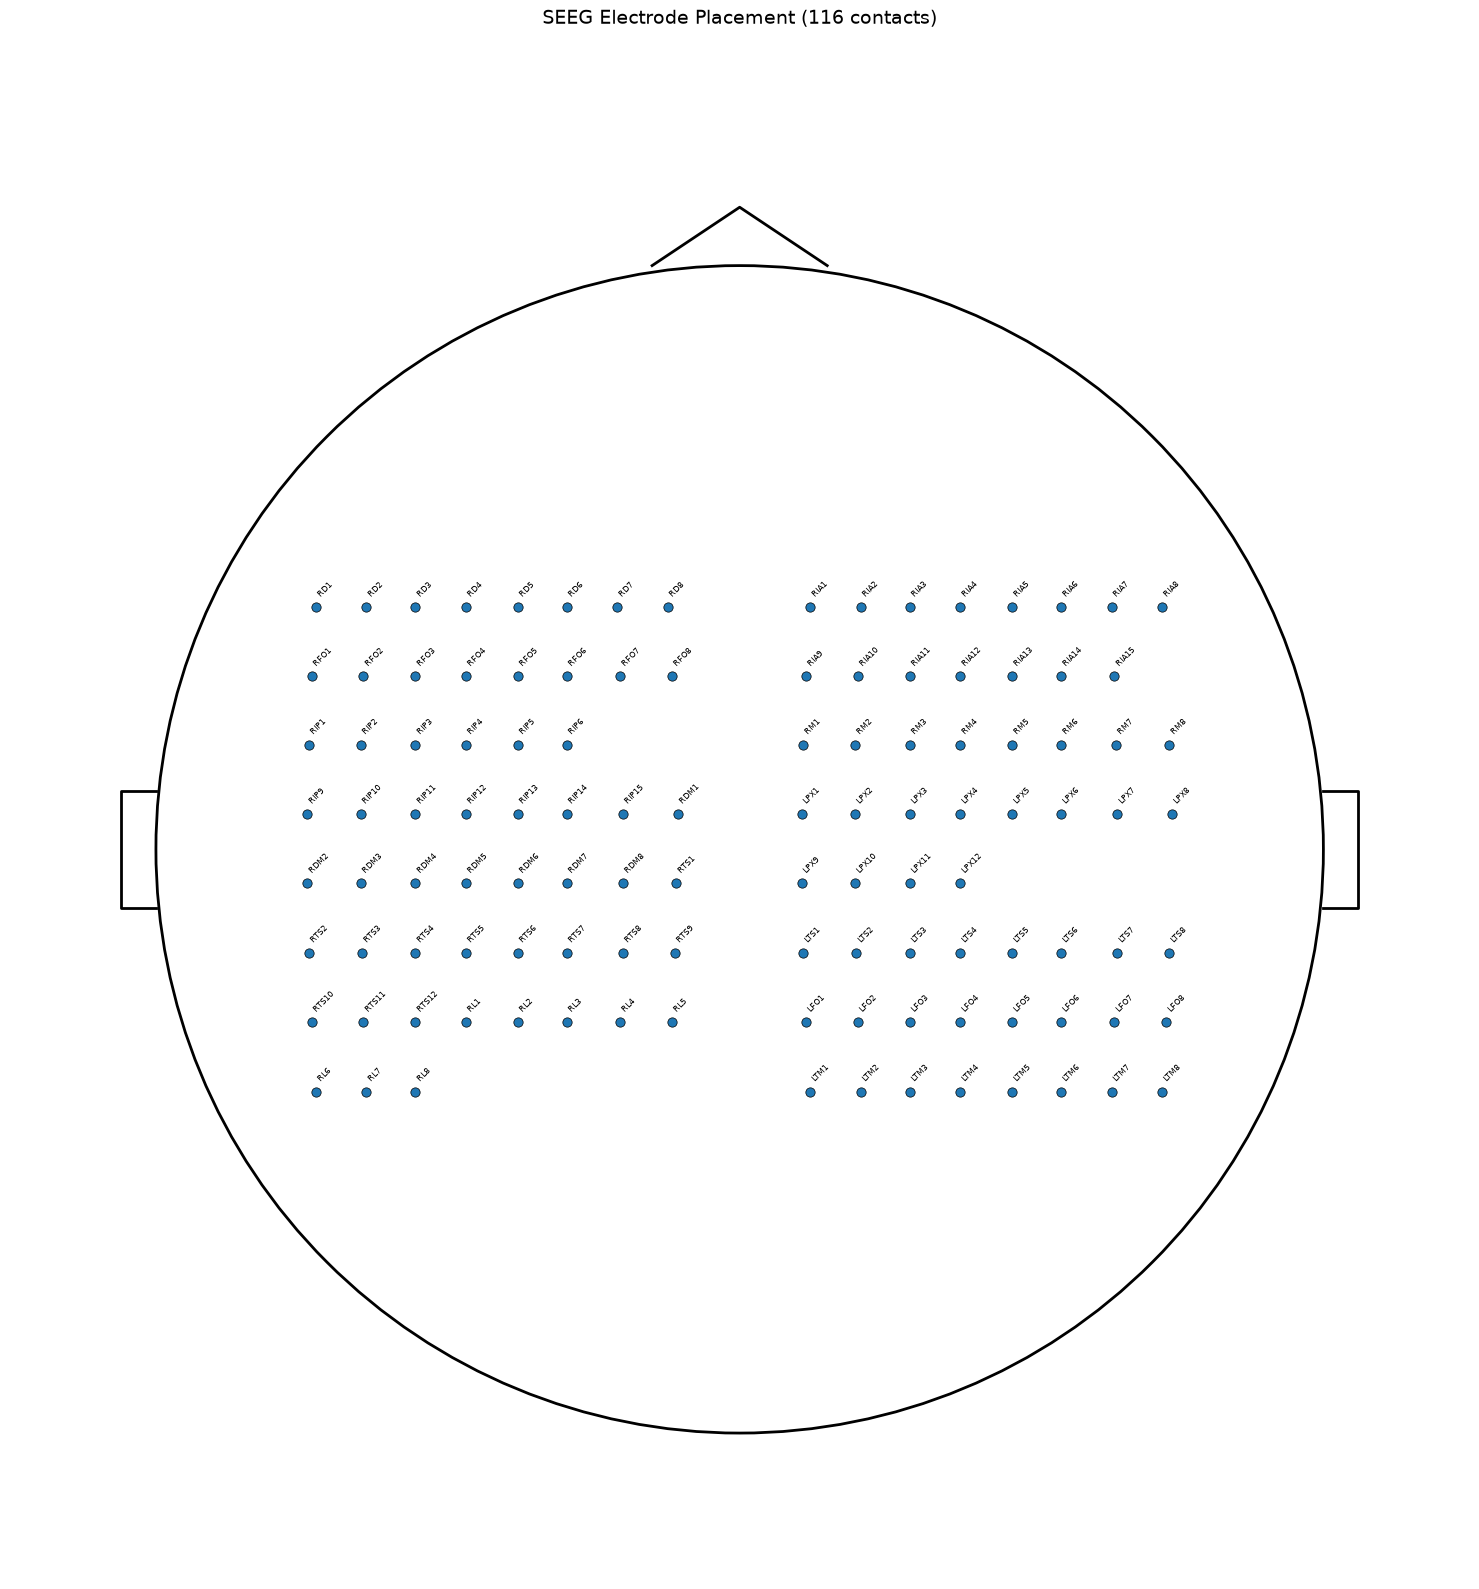

In [8]:
import xml.etree.ElementTree as ET
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.lines import Line2D

# ==============================================================================
# 1. PARSE XML
# ==============================================================================
def parse_electrode_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    electrodes = {}
    for elec in root.iter("Electrode"):
        label = elec.find("Label").text
        x = float(elec.find("XCoordinate").text)
        y = float(elec.find("YCoordinate").text)
        group_id = elec.find("GroupId").text
        electrodes[label] = {"x": x, "y": y, "group": group_id}
    return electrodes


xml_path = XML_PATH
electrodes = parse_electrode_xml(xml_path)
print(f"Parsed {len(electrodes)} electrode contacts")

# ==============================================================================
# 2. AUTO-FIT HEAD CIRCLE TO ACTUAL DATA BOUNDS
# ==============================================================================
xs = [v["x"] for v in electrodes.values()]
ys = [v["y"] for v in electrodes.values()]

data_cx = (min(xs) + max(xs)) / 2
data_cy = (min(ys) + max(ys)) / 2
half_width = (max(xs) - min(xs)) / 2
half_height = (max(ys) - min(ys)) / 2

# Head radius = distance to the farthest point, plus 20% padding
radius = max(half_width, half_height) * 1.35

# ==============================================================================
# 3. COLOR PER SHAFT (auto-pick colormap based on number of groups)
# ==============================================================================
groups = sorted(set(v["group"] for v in electrodes.values()), key=int)
n_groups = len(groups)
cmap = plt.colormaps["tab20"].resampled(n_groups) if n_groups <= 20 else plt.colormaps["hsv"].resampled(n_groups)
group_color = {g: cmap(i) for i, g in enumerate(groups)}

# ==============================================================================
# 4. DRAW HEAD OUTLINE
# ==============================================================================
def draw_head_outline(ax, center, radius):
    cx, cy = center
    head = Circle((cx, cy), radius, fill=False, linewidth=2, zorder=1)
    ax.add_patch(head)

    nose_width = radius * 0.15
    nose_height = radius * 0.10
    nose = Line2D(
        [cx - nose_width, cx, cx + nose_width],
        [cy - radius, cy - radius - nose_height, cy - radius],
        color="black", linewidth=2, zorder=1
    )
    ax.add_line(nose)

    ear_width = radius * 0.06
    ear_height = radius * 0.20
    for side in [-1, 1]:
        ear_x = cx + side * radius
        ear = Line2D(
            [ear_x, ear_x + side * ear_width, ear_x + side * ear_width, ear_x],
            [cy - ear_height / 2, cy - ear_height / 2, cy + ear_height / 2, cy + ear_height / 2],
            color="black", linewidth=2, zorder=1
        )
        ax.add_line(ear)


# ==============================================================================
# 5. PLOT
# ==============================================================================
fig, ax = plt.subplots(figsize=(16, 16))

draw_head_outline(ax, center=(data_cx, data_cy), radius=radius)

for label, v in electrodes.items():
    x, y = v["x"], v["y"]
    color = group_color[v["group"]]
    ax.scatter(x, y, s=45, color=color, zorder=3, edgecolors="black", linewidths=0.5)
    ax.annotate(
        label, (x, y),
        textcoords="offset points", xytext=(0, 6),
        fontsize=6, rotation=45, ha="left", va="bottom", zorder=4
    )

ax.set_title(f"SEEG Electrode Placement ({len(electrodes)} contacts)", fontsize=14)
ax.invert_yaxis()
ax.set_aspect("equal")

margin = radius * 0.25
ax.set_xlim(data_cx - radius - margin, data_cx + radius + margin)
ax.set_ylim(data_cy + radius + margin, data_cy - radius - margin - radius * 0.15)  # extra room for nose
ax.axis("off")

plt.tight_layout()
plt.savefig("electrode_placement_head.png", dpi=300, bbox_inches="tight")
plt.show()